In [1]:
# Only needed for VS Code - change cwd to the notebook's directory for VS Code 
import os

try:
    notebook_path = globals()['__vsc_ipynb_file__']
    notebook_dir = os.path.dirname(notebook_path)
    os.chdir(notebook_dir)
    print(f"Changed directory to: {notebook_dir}")
except:
    print("ERROR. Could not find notebook path. Running from:", os.getcwd())

Changed directory to: /lustre/groups/imm01/workspace/yang/DextraDemixer/experiments/synthetic_benchmark


In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import os

# Example of simulated datasets

In [3]:
EXPERIMENT_PATH = 'benchmarks/synth_benchmark'
os.makedirs('../../figures/', exist_ok=True)

In [4]:
import muon as mu
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="mudata")
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")
warnings.filterwarnings("ignore", message=".*Transforming to str index.*")


/opt/conda/envs/dextrademixer/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/conda/envs/dextrademixer/lib/python3.13/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


/opt/conda/envs/dextrademixer/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)
/opt/conda/envs/dextrademixer/lib/python3.13/site-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)


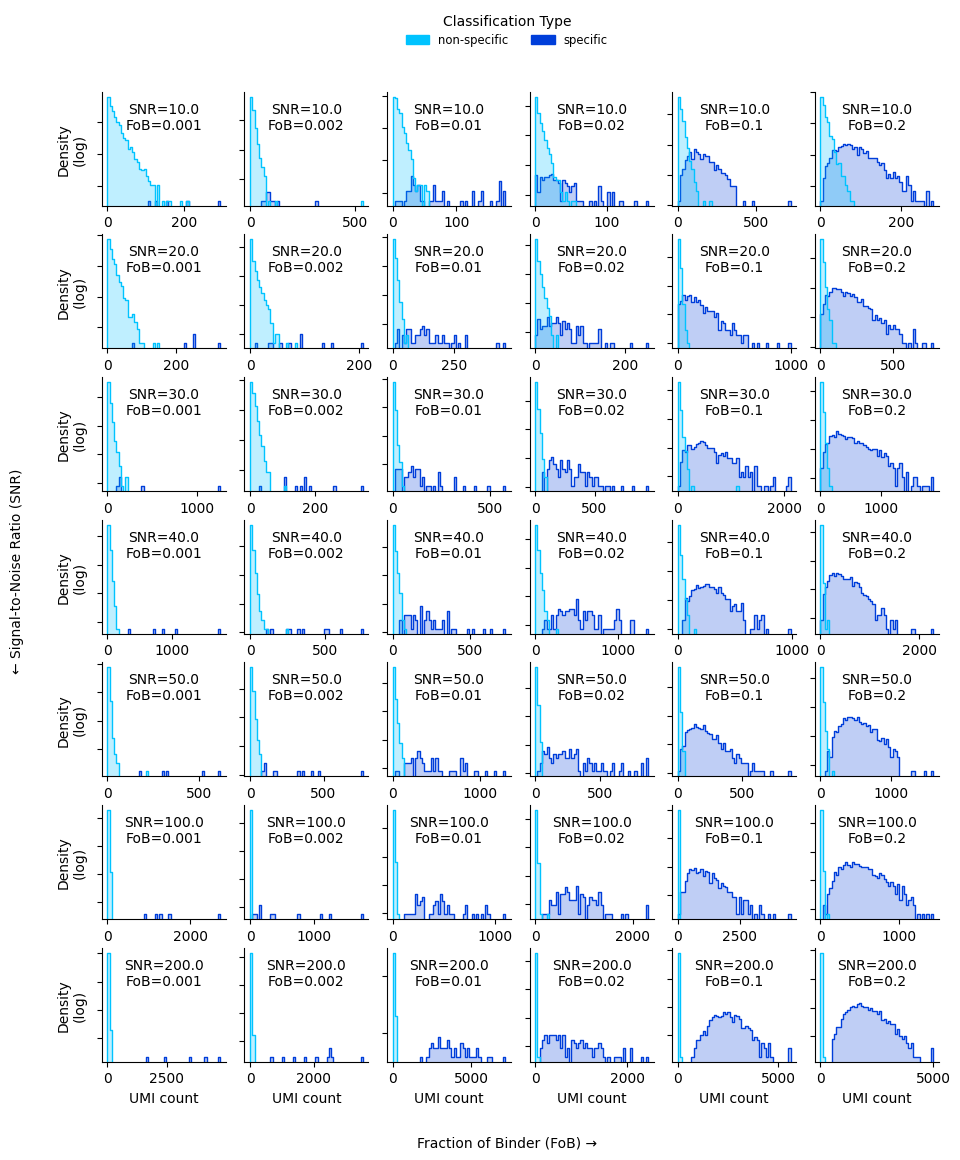

In [5]:
total_cells = 5000
binding_ratios = [0.001, 0.002, 0.01, 0.02, 0.1, 0.2,]
mean_incs = [10.0, 20.0, 30.0, 40.0, 50.0, 100.0, 200.0] 
hue = 'is_binder'
log_scale = True

dataframes = []
for binding_ratio in binding_ratios:
    for mean_inc in mean_incs:
        mdata = mu.read(os.path.join(EXPERIMENT_PATH, f'simulation/{total_cells},0.4,0.0,{binding_ratio},False,{mean_inc},None,0.h5mu'))
        df_ = mdata.mod['airr'].obs.copy()
        df_['x_umi'] = mdata['gex'][:, 'pmhc1'].X.toarray().flatten()
        df_['FoB'] = binding_ratio
        df_['SNR'] = mean_inc
        dataframes.append(df_)
combined_df = pd.concat(dataframes, ignore_index=True)

custom_colors = {0: "#00C3FF", 1: "#003eda", }
hue_order = [0, 1,]
g = sns.FacetGrid( data=combined_df, row='SNR', col='FoB', sharex=False, sharey=False, height=1.8, aspect=1.0, gridspec_kws={'wspace': 0.15, 'hspace': 0.25} )
g.map_dataframe(sns.histplot, x='x_umi', hue=hue, hue_order=hue_order, stat='density', bins=50, palette=custom_colors, legend=False, element='step')

g.set_titles("{row_var}={row_name}\n{col_var}={col_name}", y=0.6, fontsize=6)
g.set(yscale='log' if log_scale else 'linear')
g.fig.supxlabel("Fraction of Binder (FoB) →", fontsize='medium', y=0.04)
g.fig.supylabel("← Signal-to-Noise Ratio (SNR)", fontsize='medium', x=0.04)

g.set(yticklabels=[])
g.set_axis_labels("", "")

for ax in g.axes.flat:
    title_text = ax.get_title()
    ax.set_title(title_text, fontsize=10, y=0.6)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.tick_params(axis='y', which='minor', left=False, right=False)

for ax in g.axes[6, :]:
    ax.set_xlabel("UMI count", fontsize=10)
    
for ax in g.axes[:, 0]:
    ax.set_ylabel(f"Density\n({'log' if log_scale else 'linear'})", fontsize=10)

legend_handles = [mpatches.Patch(color=color, label={0: 'non-specific', 1: 'specific'}[label]) for label, color in custom_colors.items()]
g.fig.legend( handles=legend_handles, title="True binding status" if hue == 'y_true' else "Classification Type", 
                loc="upper center", bbox_to_anchor=(0.5, 0.95), ncol=4, frameon=False, fontsize='small')

g.fig.subplots_adjust(wspace=0, hspace=0)
plt.savefig(f'../../figures/SuppFig3_Sim_examples_{"log" if log_scale else "linear"}_{hue}.pdf', bbox_inches='tight')
plt.savefig(f'../../figures/SuppFig3_Sim_examples_{"log" if log_scale else "linear"}_{hue}.png', bbox_inches='tight', dpi=300)
plt.show()